# M1 method


## From scratch

In [7]:
import pandas as pd
import numpy as np
from util.filter_data import filtering
from methods.decision_tree_scratch import DecisionTreeScratch

df1 = filtering('src/claims_train.csv')

def kfold_split(n_samples, k=5, seed=42):
    np.random.seed(seed)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    return np.array_split(indices, k)


def cross_validate_tree(df, target_col, tree_class, features, k=5, seed=42, **tree_kwargs):
    folds = kfold_split(len(df), k=k, seed=seed)
    mse_scores = []
    best_tree = None
    best_mse = float("inf")

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.setdiff1d(np.arange(len(df)), val_idx)

        # selcts features and target column
        X_train = df.iloc[train_idx][features].to_numpy()
        y_train = df.iloc[train_idx][target_col].to_numpy()
        X_val = df.iloc[val_idx][features].to_numpy()
        y_val = df.iloc[val_idx][target_col].to_numpy()

        # trains tree using the hyperparameters
        tree = tree_class(**tree_kwargs)
        tree.fit(X_train, y_train)

        # pruining
        tree.prune(X_val, y_val)

        # Evaluate validation MSE
        y_val_pred = tree.predict(X_val)
        mse = np.mean((y_val - y_val_pred)**2)
        mse_scores.append(mse)

        # Keep the best tree
        if mse < best_mse:
            best_mse = mse
            best_tree = tree

        print(f"Fold {i+1}/{k} - Validation MSE: {mse:.4f}")

    print(f"Best validation MSE: {best_mse:.4f}")
    return mse_scores, best_tree

def predict_tree(tree, df, features):
    X = df[features].to_numpy()
    return tree.predict(X)


features = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

# Perform 5-fold CV and get the best tree
mse_scores, best_tree = cross_validate_tree(
    df=df1,
    target_col="Risk",
    tree_class=DecisionTreeScratch,
    features=features,
    k=5,
    max_depth=5,
    min_samples_split=20
)

# Predict a single row
single_row = df1.iloc[0:1]  # keep as DataFrame
pred_single = predict_tree(best_tree, single_row, features)
print(f"Predicted risk for single row: {pred_single[0]:.5f}")
# First 10 actual target values
actual_values = df1["Risk"].iloc[:10]
print("Actual risk values for first 10 rows:")
print(actual_values.values)


# Predict multiple rows
pred_batch = predict_tree(best_tree, df1.iloc[:10], features)
print("Predictions for first 10 rows:", pred_batch)

Fold 1/5 - Validation MSE: 0.0285
Fold 2/5 - Validation MSE: 0.0286
Fold 3/5 - Validation MSE: 0.0284
Fold 4/5 - Validation MSE: 0.0286
Fold 5/5 - Validation MSE: 0.0284
Best validation MSE: 0.0284
Predicted risk for single row: 0.21920
Actual risk values for first 10 rows:
[0.44779761 0.59454042 0.37738764 0.19304709 0.59454042 0.4276604
 0.08701661 0.08701661 0.10427201 0.0935331 ]
Predictions for first 10 rows: [0.21919506 0.23282468 0.18120818 0.26987773 0.35539316 0.21919506
 0.26987773 0.2019538  0.24901564 0.26987773]


# M2 method - Neural Network


## From scratch

In [7]:
from methods.neural_network_scratch import NeuralNetworkScratch
from util.filter_data import filtering
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler

df = filtering('src/claims_train.csv', alpha=2, gamma=0.1, train=True)
df_test = filtering('src/claims_test.csv', alpha=2, gamma=0.1, train=True)

Y = df['Risk'].values.astype(np.float32).reshape(-1, 1)
df_clean = df.drop(columns=["IDpol", "ClaimNb", "Exposure","Region",'Risk'])
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns

X_cat = pd.get_dummies(df_clean[categorical_cols], drop_first=True)
df_clean = df_clean.drop(columns=categorical_cols)
X_final = np.hstack([df_clean, X_cat.values])

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final).astype(np.float32)


Y_test = df_test['Risk'].values.astype(np.float32).reshape(-1, 1)
df_clean_test = df_test.drop(columns=["IDpol", "ClaimNb", "Exposure","Region",'Risk'])
numeric_cols_test = df_clean_test.select_dtypes(include=["int64", "float64"]).columns
categorical_cols_test = df_clean_test.select_dtypes(include=["object", "category"]).columns

X_cat_test = pd.get_dummies(df_clean_test[categorical_cols_test], drop_first=True)
df_clean_test = df_clean_test.drop(columns=categorical_cols_test)
X_final_test = np.hstack([df_clean_test, X_cat_test.values])

# Feature scaling
scaler = StandardScaler()
X_scaled_test = scaler.fit_transform(X_final_test).astype(np.float32)


In [8]:
nn = NeuralNetworkScratch(
    input_dim=X_scaled.shape[1],
    hidden1_dim=128,
    hidden2_dim=64,
    output_dim=1,
    learning_rate=0.01,
    epochs=100,
    number_of_batches=400,
    random_state=1,
    patience=5,
    learning_shrink=False
)

nn.train(X_scaled, Y)

Epoch 0, Loss: 0.04446650899332965
Validation Loss: 0.04426879343953213
Epoch 1, Loss: 0.037661832201505395
Validation Loss: 0.0375410231525874
Epoch 2, Loss: 0.03493471613185602
Validation Loss: 0.034830951561165356
Epoch 3, Loss: 0.033483349494531744
Validation Loss: 0.03337444704897899
Epoch 4, Loss: 0.032644702839414105
Validation Loss: 0.03253874946393137
Epoch 5, Loss: 0.0319674462255974
Validation Loss: 0.031864781167875174
Epoch 6, Loss: 0.031490354539364225
Validation Loss: 0.03138969677812548
Epoch 7, Loss: 0.031164983427316516
Validation Loss: 0.031064592395922703
Epoch 8, Loss: 0.03087659698492771
Validation Loss: 0.030772351440442543
Epoch 9, Loss: 0.030657105871219198
Validation Loss: 0.030555946310214875
Epoch 10, Loss: 0.03046422529338005
Validation Loss: 0.030369307793359484
Epoch 11, Loss: 0.030379623549469444
Validation Loss: 0.030287064200052716
Epoch 12, Loss: 0.030144221794048846
Validation Loss: 0.03003902861977804
Epoch 13, Loss: 0.030047232236365923
Validation 

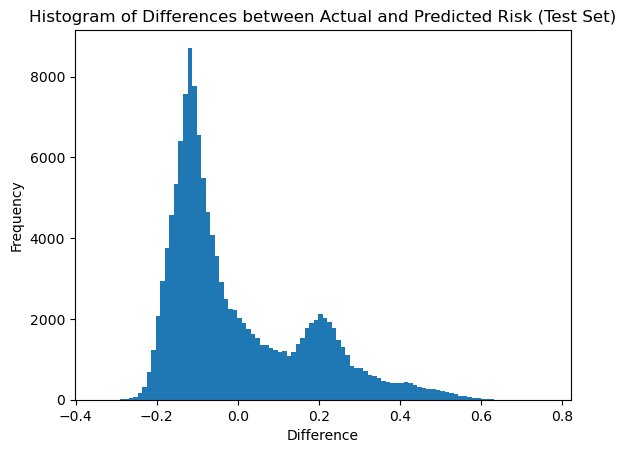

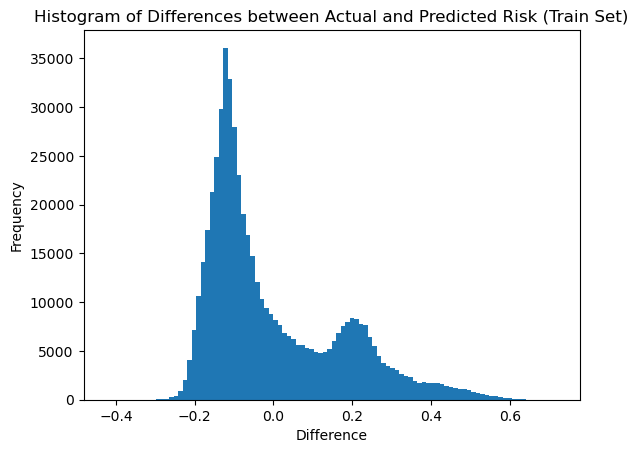

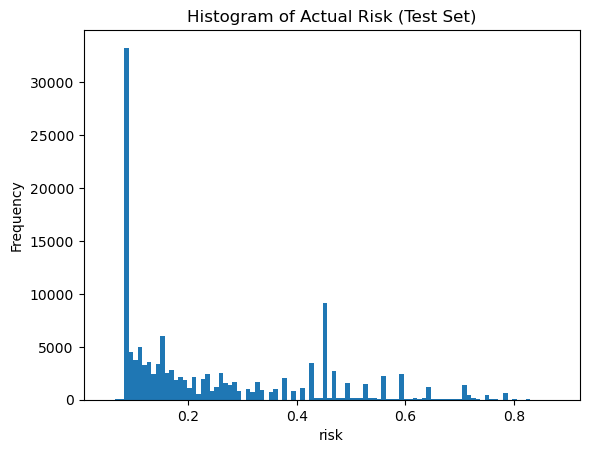

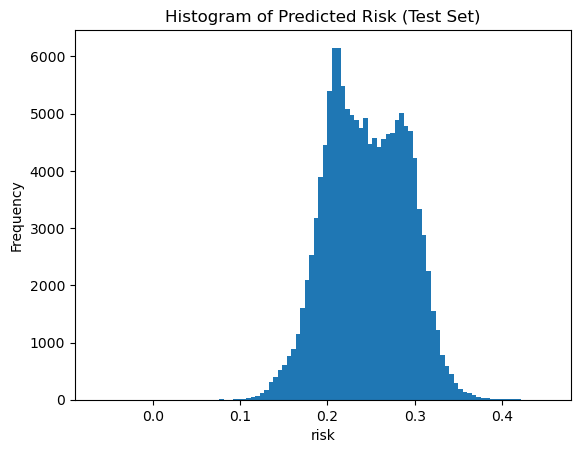

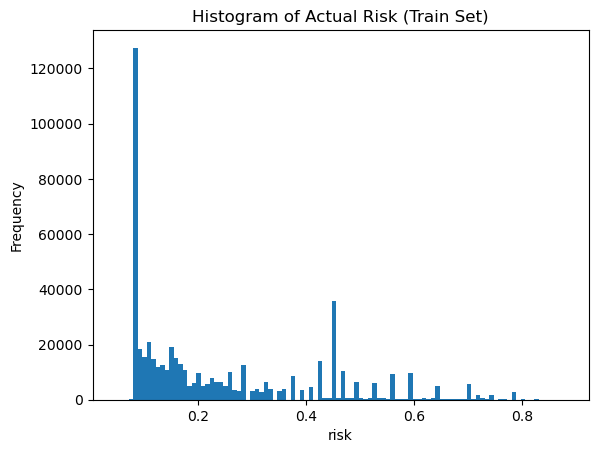

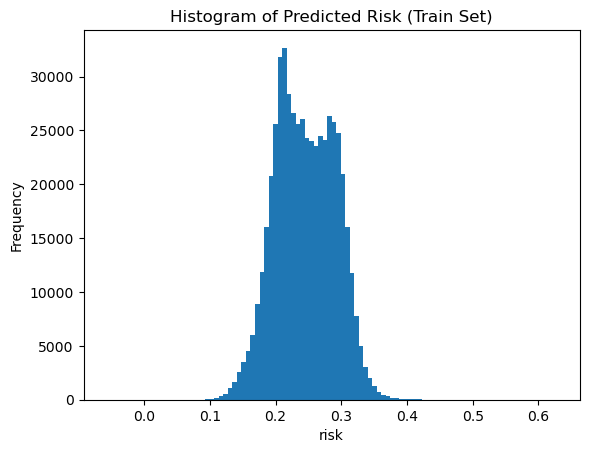

In [6]:
df_test = pd.DataFrame(Y_test)
df_test['1'] = nn.predict(X_scaled_test)
df_train = pd.DataFrame(Y)
df_train['1'] = nn.predict(X_scaled) 

difference_test=df_test[int('0')] - df_test['1']
differemce_train=df_train[int('0')] - df_train['1']
import matplotlib.pyplot as plt
plt.hist(difference_test, bins=100)
plt.title('Histogram of Differences between Actual and Predicted Risk (Test Set)')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.show()
plt.hist(differemce_train, bins=100)
plt.title('Histogram of Differences between Actual and Predicted Risk (Train Set)')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.show()

plt.hist(df_test[int('0')], bins=100)
plt.title('Histogram of Actual Risk (Test Set)')
plt.xlabel('risk')
plt.ylabel('Frequency')
plt.show()
plt.hist(df_test['1'], bins=100)
plt.title('Histogram of Predicted Risk (Test Set)')
plt.xlabel('risk')
plt.ylabel('Frequency')
plt.show()

plt.hist(df_train[int('0')], bins=100)
plt.title('Histogram of Actual Risk (Train Set)')
plt.xlabel('risk')
plt.ylabel('Frequency')
plt.show()
plt.hist(df_train['1'], bins=100)
plt.title('Histogram of Predicted Risk (Train Set)')
plt.xlabel('risk')
plt.ylabel('Frequency')
plt.show()


In [ ]:
Y_test.ravel().shape


(135603,)

## Using reference

In [28]:
from methods.neural_network_scratch import NeuralNetworkScratch
from util.filter_data import filtering
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = filtering('src/claims_train.csv', alpha=2, gamma=0.1, train=True)
df_test = filtering('src/claims_test.csv', alpha=2, gamma=0.1, train=False)

Y = df['Risk'].values.astype(np.float32).reshape(-1, 1)
df_clean = df.drop(columns=["IDpol", "ClaimNb", "Exposure","Region",'Risk'])
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns

X_cat = pd.get_dummies(df_clean[categorical_cols], drop_first=True)
df_clean = df_clean.drop(columns=categorical_cols)
X_final = np.hstack([df_clean, X_cat.values])

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final).astype(np.float32)


Y_test = df_test['Risk'].values.astype(np.float32).reshape(-1, 1)
df_clean_test = df_test.drop(columns=["IDpol", "ClaimNb", "Exposure","Region",'Risk'])
numeric_cols_test = df_clean_test.select_dtypes(include=["int64", "float64"]).columns
categorical_cols_test = df_clean_test.select_dtypes(include=["object", "category"]).columns

X_cat_test = pd.get_dummies(df_clean_test[categorical_cols_test], drop_first=True)
df_clean_test = df_clean_test.drop(columns=categorical_cols_test)
X_final_test = np.hstack([df_clean_test, X_cat_test.values])

# Feature scaling
scaler = StandardScaler()
X_scaled_test = scaler.fit_transform(X_final_test).astype(np.float32)


c:\Users\takac\ITU\semester3\machine\machine-n-learnings-inc\util\filter_data.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Region', group_keys=False).apply(remove_outliers)


c:\Users\takac\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1631: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Iteration 1, loss = 0.01805474
Iteration 2, loss = 0.01435357
Iteration 3, loss = 0.01426707
Iteration 4, loss = 0.01426896
Iteration 5, loss = 0.01418622
Iteration 6, loss = 0.01426617
Iteration 7, loss = 0.01430264
Iteration 8, loss = 0.01417125
Iteration 9, loss = 0.01416122
Iteration 10, loss = 0.01416496
Iteration 11, loss = 0.01420600
Iteration 12, loss = 0.01424551
Iteration 13, loss = 0.01417259
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
MLPRegressor train MSE: 0.028337235
MLPRegressor val   MSE: 0.028340887
MLPRegressor test  MSE: 0.028581928


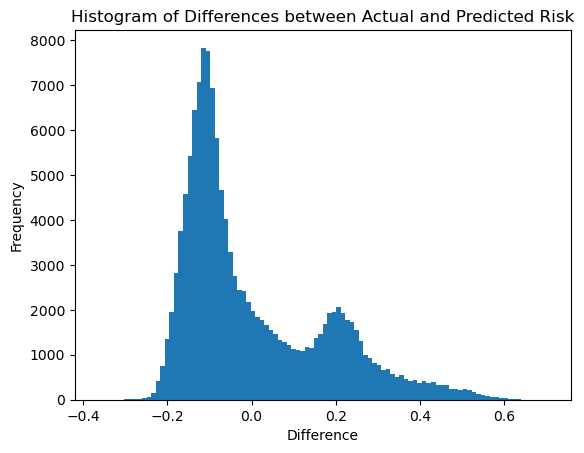

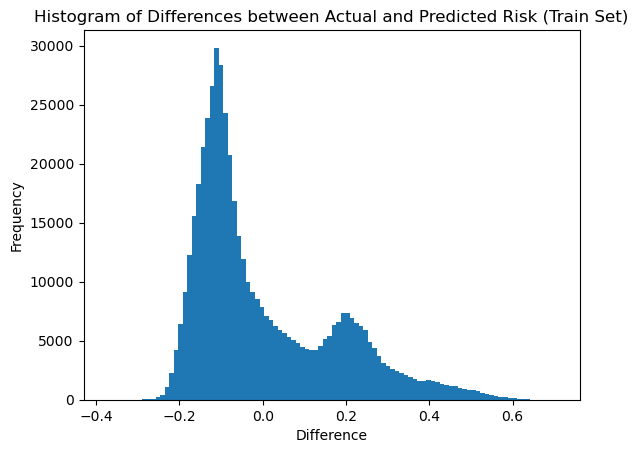

In [13]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# 80/20 train–test split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

# Define neural network
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=50,          # number of epochs
    batch_size=1000,       # mini-batch size
    random_state=42,
    verbose=True          # prints loss per iteration
)

# Train
mlp.fit(X_train, y_train)

# Predict
y_train_pred = mlp.predict(X_train)
y_val_pred   = mlp.predict(X_val)

y_test_pred = mlp.predict(X_scaled_test)

# Compute MSE
mse_train_mlp = mean_squared_error(y_train, y_train_pred)
mse_val_mlp   = mean_squared_error(y_val,   y_val_pred)
mse_test_mlp = mean_squared_error(Y_test,   y_test_pred)

print("MLPRegressor train MSE:", mse_train_mlp)
print("MLPRegressor val   MSE:", mse_val_mlp)
print("MLPRegressor test  MSE:", mse_test_mlp)

df_test = pd.DataFrame(Y_test)
df_test['1'] = nn.predict(X_scaled_test)
df_train = pd.DataFrame(Y)
df_train['1'] = nn.predict(X_scaled) 

difference_test=df_test[int('0')] - df_test['1']
differemce_train=df_train[int('0')] - df_train['1']
import matplotlib.pyplot as plt
plt.hist(difference_test, bins=100)
plt.title('Histogram of Differences between Actual and Predicted Risk')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.show()
plt.hist(differemce_train, bins=100)
plt.title('Histogram of Differences between Actual and Predicted Risk (Train Set)')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.show()

# M3 method